# Heart Disease Prediction Model
1-Problem Definition
2- Data Loading
3- Evaluate
4- Feature
5- Modeling
6- Experimentation

# libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# sklearn models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
# Evaluation Metrics
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.metrics import RocCurveDisplay

# Exploratory Data Analysis
* 1- what problem to be solved
* 2- what kind of data i have
* 3- does this data any missing values
* 4- are any outliers, sporious vectors
* 5- can we add or remove some features



In [2]:
dataset = pd.read_csv("heart.csv")

In [3]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
dataset.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


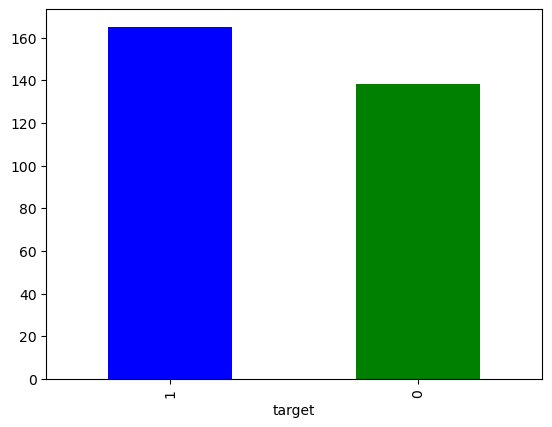

In [5]:
dataset["target"].value_counts().plot(kind="bar", color=["blue","green"]);

In [6]:
dataset.isna().sum() # checking for any missing values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## 1-# Gender vs target

In [7]:
# lets plot the sex vs target ratio, How much males and females are likely to are diseased and vice versa
pd.crosstab(dataset.target,dataset.sex)

sex,0,1
target,,
0,24,114
1,72,93


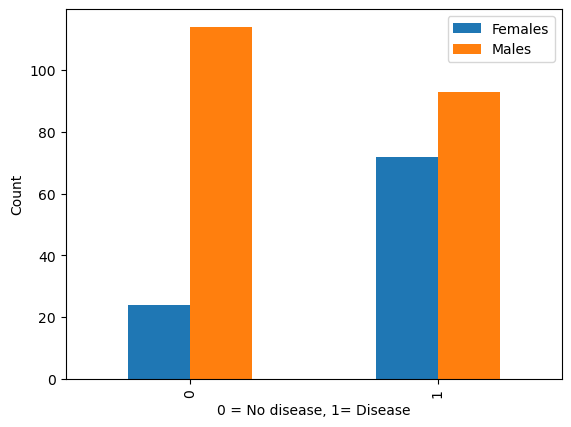

In [8]:
pd.crosstab(dataset.target,dataset.sex).plot(kind="bar")
plt.xlabel("0 = No disease, 1= Disease")
plt.ylabel("Count")
plt.legend(['Females','Males'])

## 2- Age Distribution Vs Heart Disease

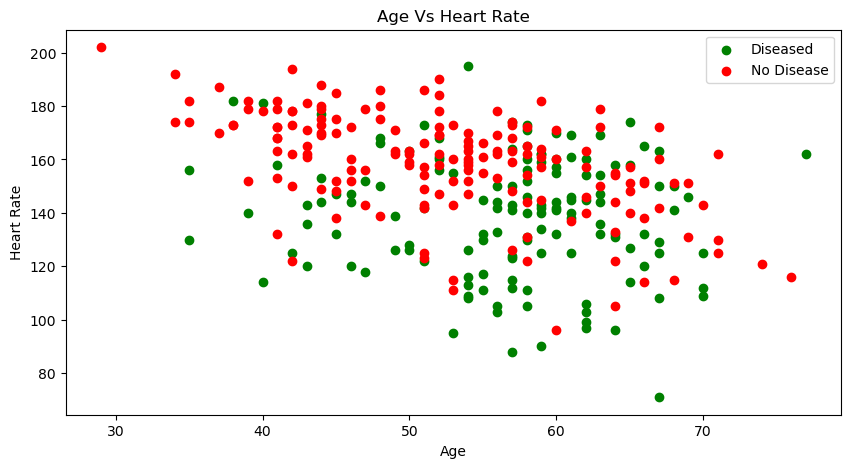

In [9]:
# finding the other patterns;;;
# take a look at the age vs thalach in a scatter plot
plt.figure(figsize = (10,5))
# the results will be completely different when target is set to DISEASED(0) and NOT dISEASED(1)
plt.scatter(dataset.age[dataset.target==0],dataset.thalach[dataset.target==0],c="green");
plt.scatter(dataset.age[dataset.target==1],dataset.thalach[dataset.target==1],c="red");
plt.title("Age Vs Heart Rate")
plt.xlabel("Age")
plt.ylabel("Heart Rate")
plt.legend(["Diseased","No Disease"])

<Axes: ylabel='Frequency'>

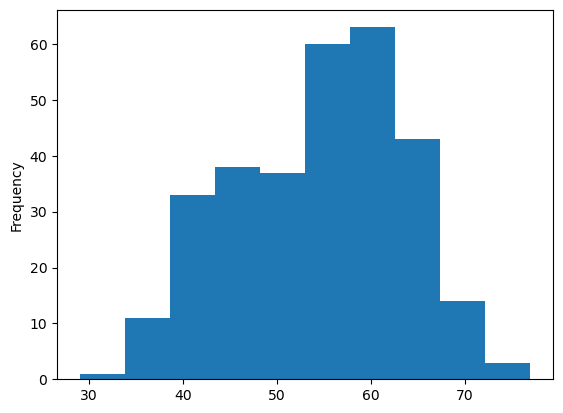

In [10]:
# check the age distribution
dataset.age.plot.hist()
# it is clear that people which are old, above 50 years are more likely to have heart disorders than the younger ones
# the histogram also shows that the perfect gaussian distribution is not achieved here// perfect gaussian is above the middle(peek) and
# and lower at the both the left and right

## 3-Chest Pain Type Vs Heart Disease

In [11]:
dataset.cp.value_counts()

cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64

## cp(chest pain)
    -- Value 0: typical angina
    -- Value 1: atypical angina
    -- Value 2: non-anginal pain
    -- Value 3: asymptomatic

In [6]:
pd.crosstab(dataset.cp,dataset.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


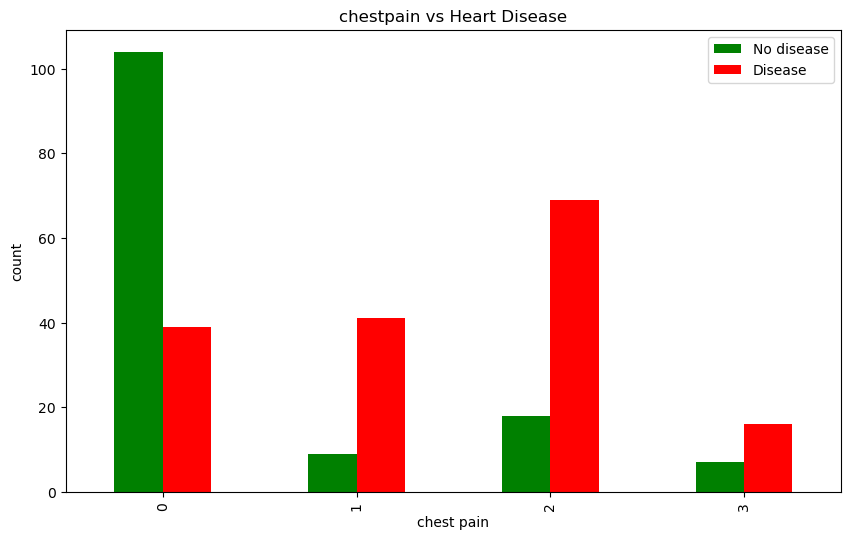

In [8]:
pd.crosstab(dataset.cp,dataset.target).plot(kind="bar",
                                           figsize=(10,6),
                                           color=['green','red'])
plt.title("chestpain vs Heart Disease")
plt.ylabel("count")
plt.xlabel("chest pain")
plt.legend(["No disease","Disease"])


## Correlation Matrix
### shows relation of all the indvidual fields with all the other fields

In [10]:
 # simply do this
dataset.corr()
# u will get Negative, positive and maximum correaltions

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


## plotting correlation Matrix

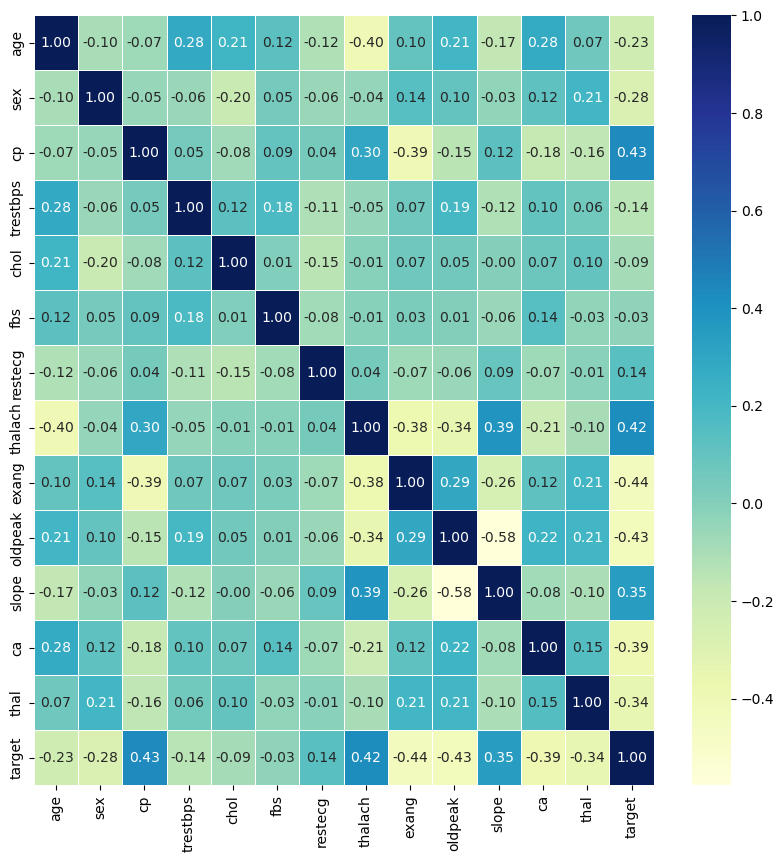

In [13]:
cor_map = dataset.corr()
figure,plot1 = plt.subplots(figsize = (10,10))
plot1 = sns.heatmap(cor_map,
                   annot = True,
                   linewidths=0.5,
                   fmt="0.2f",
                   cmap="YlGnBu");

# Split the Data set and choose the Model

In [4]:
X = dataset.drop("target",axis=1)
Y = dataset["target"]

In [5]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2)

In [21]:
# let us try three different models, and note which one score is better
models = {
    "KNN":KNeighborsClassifier(),
    "Rand Forest Classfier":RandomForestClassifier(),
    "Logistic Regression":LogisticRegression()
}
# creating a fun for evaluating these models
def fit_and_score(models,x_train,x_test,y_train,y_test):
    model_score = {}
    
    for name, model in models.items():
        np.random.seed(7)
        model.fit(x_train,y_train)
        # model evaluation
        model_score[name] = model.score(x_test,y_test)
    return model_score

In [23]:
fit_and_score(models=models,x_train=x_train,x_test=x_test,y_train=y_train,y_test=y_test)

c:\ml1\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.7377049180327869,
 'Rand Forest Classfier': 0.8524590163934426,
 'Logistic Regression': 0.8360655737704918}

## Improving Models, Techniques
* Tuning Hyperparameters
* features Engineering
### Advanced Techniques
* confusion Matrix
* cross validation
* precision
* Recall
* f1
* Classification Report

In [7]:
train_score = []
test_score = []
# testing hyperparameters for knn model
n_neighbor = range(1,30)
knn = KNeighborsClassifier()
# looping throu the range
for i in n_neighbor:
    knn.set_params(n_neighbors=i)
    # now fit the model and check score
    knn.fit(x_train,y_train)
    train_score.append(knn.score(x_train,y_train))
    test_score.append(knn.score(x_test,y_test))

In [8]:
train_score

[1.0,
 0.8057851239669421,
 0.7933884297520661,
 0.7603305785123967,
 0.7851239669421488,
 0.7603305785123967,
 0.7396694214876033,
 0.7520661157024794,
 0.71900826446281,
 0.731404958677686,
 0.7272727272727273,
 0.7024793388429752,
 0.7231404958677686,
 0.7107438016528925,
 0.7107438016528925,
 0.731404958677686,
 0.7024793388429752,
 0.7024793388429752,
 0.6942148760330579,
 0.6983471074380165,
 0.6983471074380165,
 0.6942148760330579,
 0.6900826446280992,
 0.6859504132231405,
 0.6942148760330579,
 0.6942148760330579,
 0.7066115702479339,
 0.6983471074380165,
 0.6983471074380165]

In [9]:
test_score

[0.5901639344262295,
 0.4098360655737705,
 0.6065573770491803,
 0.5245901639344263,
 0.5901639344262295,
 0.5573770491803278,
 0.5737704918032787,
 0.5245901639344263,
 0.47540983606557374,
 0.5409836065573771,
 0.5573770491803278,
 0.5737704918032787,
 0.6065573770491803,
 0.5901639344262295,
 0.6229508196721312,
 0.6065573770491803,
 0.6557377049180327,
 0.639344262295082,
 0.6721311475409836,
 0.6229508196721312,
 0.6721311475409836,
 0.6721311475409836,
 0.6885245901639344,
 0.6885245901639344,
 0.6885245901639344,
 0.639344262295082,
 0.6557377049180327,
 0.639344262295082,
 0.6721311475409836]